**Problem No**: 04

**Problem Statement**: Take a grayscale image and apply gamma transformation image operations (y=0.2,y=0.4,y=0.6,y=1.0,y=1.5,y=2.5,y=5.0). Show input and output image side by side in a subplot with a title. Use PyPlot to plot the gamma transformation.

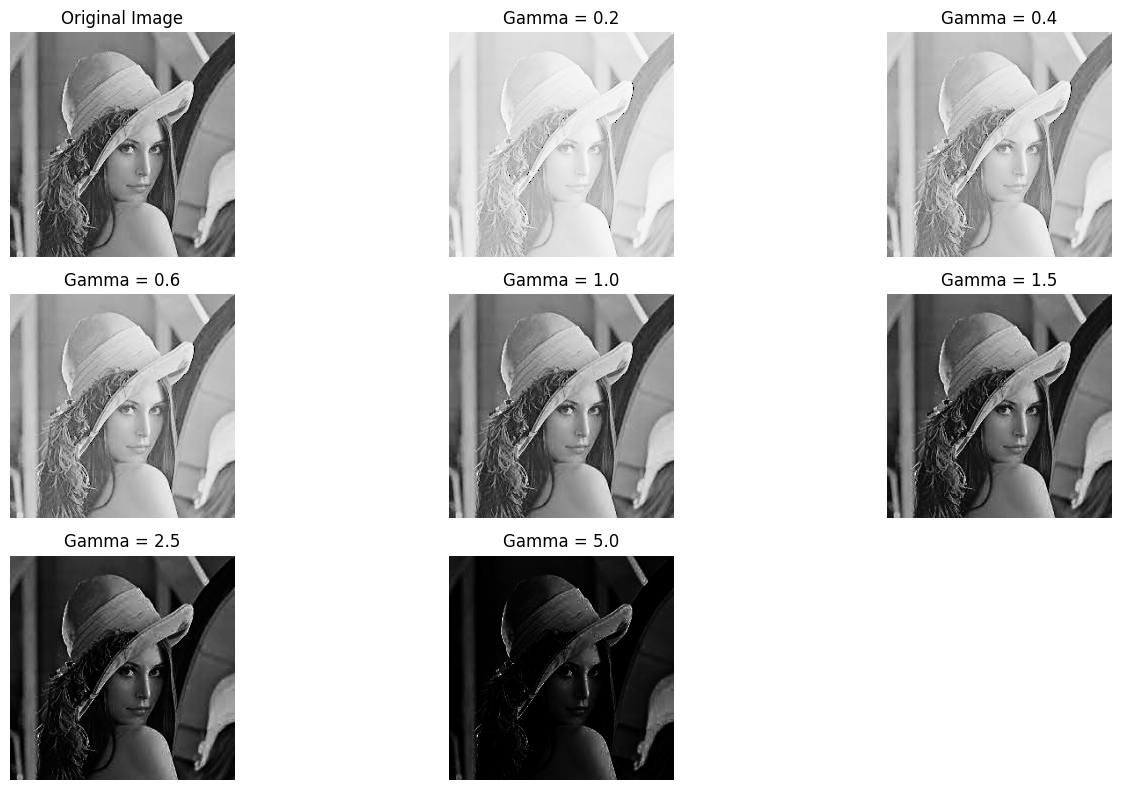

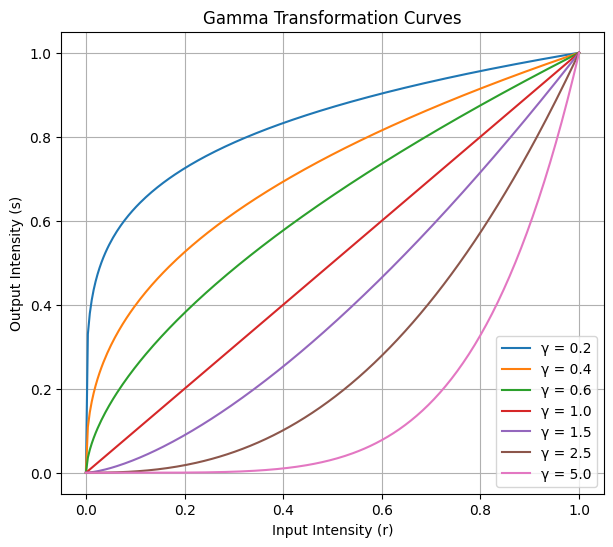

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read grayscale image
img = cv2.imread("a.jpg", cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Image not found!")
    exit()

# Convert to float 
img_float = img.astype(np.float64)

# Bit depth
L = 256  # For 8-bit grayscale

gammas = [0.2, 0.4, 0.6, 1.0, 1.5, 2.5, 5.0]
gamma_images = []

# Apply gamma transformation
for g in gammas:
    gamma_img = np.zeros_like(img_float)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            r = img_float[i][j] / (L - 1)   # Normalize
            s = (L - 1) * (r ** g)
            gamma_img[i][j] = s

    gamma_img = np.clip(gamma_img, 0, L-1).astype(np.uint8)
    gamma_images.append(gamma_img)

# -----------------------------
# Show Images
# -----------------------------
plt.figure(figsize=(14,8))

plt.subplot(3,3,1)
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.title("Original Image")
plt.axis('off')

for idx, g in enumerate(gammas):
    plt.subplot(3,3,idx+2)
    plt.imshow(gamma_images[idx], cmap='gray', vmin=0, vmax=255)
    plt.title(f"Gamma = {g}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# -----------------------------
# Plot Gamma Curves
# -----------------------------
r = np.linspace(0, 1, 256)

plt.figure(figsize=(7,6))

for g in gammas:
    s = r ** g
    plt.plot(r, s, label=f"γ = {g}")

plt.title("Gamma Transformation Curves")
plt.xlabel("Input Intensity (r)")
plt.ylabel("Output Intensity (s)")
plt.legend()
plt.grid(True)
plt.show()